# Linear Regression Stock price Prediction

## 1. Importing the libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

## 12. loading the data

In [3]:
#taking the input to ask the user to choose the company
name = input("Enter the name of the company").upper()
name

#taking the dataset 
df = pd.read_csv(f"../data-companywise/processed_data/{name}.csv")
df

Enter the name of the company ebl


,date,open,high,low,close,price_change_pct,volume,turnover,year,eps,pe-ratio,roe,dividend
0,2022-01-02,536.0,551.8,532.0,548.0,2.37,40142.0,21819449.0,2022,28.25,16.8,14.55,20.0
1,2022-01-03,552.0,576.0,551.1,573.9,4.73,65836.0,37353840.5,2022,28.25,16.8,14.55,20.0
2,2022-01-04,571.0,625.0,560.1,615.0,7.16,77227.0,45958834.5,2022,28.25,16.8,14.55,20.0
3,2022-01-05,615.0,618.9,591.0,597.0,-2.93,70010.0,42303701.4,2022,28.25,16.8,14.55,20.0
4,2022-01-06,598.0,618.0,588.4,614.0,2.85,40796.0,24616154.7,2022,28.25,16.8,14.55,20.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
936,2026-01-14,661.0,665.0,658.0,660.0,-0.15,26659.0,17620601.8,2026,NaN,NaN,NaN,NaN
937,2026-01-18,660.5,667.0,660.0,665.2,0.79,27585.0,18338376.8,2026,NaN,NaN,NaN,NaN
938,2026-01-20,665.0,682.0,665.0,677.0,1.77,35963.0,24352280.6,2026,NaN,NaN,NaN,NaN
939,2026-01-21,678.1,680.0,671.0,673.0,-0.59,13721.0,9236861.1,2026,NaN,NaN,NaN,NaN


## 3. Dropping the unnecessary columns

In [4]:
#eps, pe, roe and dividend, turnover, year
df.drop(columns = ['eps','roe','dividend','pe-ratio', 'year','turnover'],inplace = True)
df

,date,open,high,low,close,price_change_pct,volume
0,2022-01-02,536.0,551.8,532.0,548.0,2.37,40142.0
1,2022-01-03,552.0,576.0,551.1,573.9,4.73,65836.0
2,2022-01-04,571.0,625.0,560.1,615.0,7.16,77227.0
3,2022-01-05,615.0,618.9,591.0,597.0,-2.93,70010.0
4,2022-01-06,598.0,618.0,588.4,614.0,2.85,40796.0
...,...,...,...,...,...,...,...
936,2026-01-14,661.0,665.0,658.0,660.0,-0.15,26659.0
937,2026-01-18,660.5,667.0,660.0,665.2,0.79,27585.0
938,2026-01-20,665.0,682.0,665.0,677.0,1.77,35963.0
939,2026-01-21,678.1,680.0,671.0,673.0,-0.59,13721.0


In [5]:
# reviewing the data
print(df.head())
print(df.shape)
print(df.dtypes)

         date   open   high    low  close  price_change_pct   volume
0  2022-01-02  536.0  551.8  532.0  548.0              2.37  40142.0
1  2022-01-03  552.0  576.0  551.1  573.9              4.73  65836.0
2  2022-01-04  571.0  625.0  560.1  615.0              7.16  77227.0
3  2022-01-05  615.0  618.9  591.0  597.0             -2.93  70010.0
4  2022-01-06  598.0  618.0  588.4  614.0              2.85  40796.0
(941, 7)
date                 object
open                float64
high                float64
low                 float64
close               float64
price_change_pct    float64
volume              float64
dtype: object


## 4. Cleaning and preparing the data

In [6]:
df['date'] = pd.to_datetime(df['date'])
df =  df.sort_values('date').reset_index(drop = True)
df

,date,open,high,low,close,price_change_pct,volume
0,2022-01-02,536.0,551.8,532.0,548.0,2.37,40142.0
1,2022-01-03,552.0,576.0,551.1,573.9,4.73,65836.0
2,2022-01-04,571.0,625.0,560.1,615.0,7.16,77227.0
3,2022-01-05,615.0,618.9,591.0,597.0,-2.93,70010.0
4,2022-01-06,598.0,618.0,588.4,614.0,2.85,40796.0
...,...,...,...,...,...,...,...
936,2026-01-14,661.0,665.0,658.0,660.0,-0.15,26659.0
937,2026-01-18,660.5,667.0,660.0,665.2,0.79,27585.0
938,2026-01-20,665.0,682.0,665.0,677.0,1.77,35963.0
939,2026-01-21,678.1,680.0,671.0,673.0,-0.59,13721.0


In [7]:
#checking for the null values
df.isnull().sum()

date                0
open                0
high                0
low                 0
close               0
price_change_pct    0
volume              0
dtype: int64

In [8]:
#total traded days
print(f"total trading days :{len(df)}")

total trading days :941


In [9]:
# 3. Set as index
df.set_index('date', inplace=True)


In [10]:
df

,open,high,low,close,price_change_pct,volume
date,,,,,,
2022-01-02,536.0,551.8,532.0,548.0,2.37,40142.0
2022-01-03,552.0,576.0,551.1,573.9,4.73,65836.0
2022-01-04,571.0,625.0,560.1,615.0,7.16,77227.0
2022-01-05,615.0,618.9,591.0,597.0,-2.93,70010.0
2022-01-06,598.0,618.0,588.4,614.0,2.85,40796.0
...,...,...,...,...,...,...
2026-01-14,661.0,665.0,658.0,660.0,-0.15,26659.0
2026-01-18,660.5,667.0,660.0,665.2,0.79,27585.0
2026-01-20,665.0,682.0,665.0,677.0,1.77,35963.0


## 5. Feature Enginneering

In [11]:
#here no use of open, high, low
column_to_drop = ['open','high','low']
df.drop(columns = column_to_drop, inplace= True)
df

,close,price_change_pct,volume
date,,,
2022-01-02,548.0,2.37,40142.0
2022-01-03,573.9,4.73,65836.0
2022-01-04,615.0,7.16,77227.0
2022-01-05,597.0,-2.93,70010.0
2022-01-06,614.0,2.85,40796.0
...,...,...,...
2026-01-14,660.0,-0.15,26659.0
2026-01-18,665.2,0.79,27585.0
2026-01-20,677.0,1.77,35963.0


In [12]:
#adding the moving average signal to improve the performance
df['ma_7']  = df['close'].rolling(window=7).mean()
df['ma_20'] = df['close'].rolling(window=20).mean()

#shifting by 1 to avoid data leakage
df['prev_close']            = df['close'].shift(1)
df['prev_price_change_pct'] = df['price_change_pct'].shift(1)
df['prev_volume']           = df['volume'].shift(1)
df['ma_7_prev']             = df['ma_7'].shift(1)
df['ma_20_prev']            = df['ma_20'].shift(1)

In [13]:
df

,close,price_change_pct,volume,ma_7,ma_20,prev_close,prev_price_change_pct,prev_volume,ma_7_prev,ma_20_prev
date,,,,,,,,,,
2022-01-02,548.0,2.37,40142.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-03,573.9,4.73,65836.0,NaN,NaN,548.0,2.37,40142.0,NaN,NaN
2022-01-04,615.0,7.16,77227.0,NaN,NaN,573.9,4.73,65836.0,NaN,NaN
2022-01-05,597.0,-2.93,70010.0,NaN,NaN,615.0,7.16,77227.0,NaN,NaN
2022-01-06,614.0,2.85,40796.0,NaN,NaN,597.0,-2.93,70010.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2026-01-14,660.0,-0.15,26659.0,658.628571,654.380,661.0,0.09,9271.0,657.200000,653.635
2026-01-18,665.2,0.79,27585.0,660.228571,655.330,660.0,-0.15,26659.0,658.628571,654.380
2026-01-20,677.0,1.77,35963.0,663.228571,656.650,665.2,0.79,27585.0,660.228571,655.330


In [14]:
#dropping the NaN values
df.dropna(inplace = True)
df

,close,price_change_pct,volume,ma_7,ma_20,prev_close,prev_price_change_pct,prev_volume,ma_7_prev,ma_20_prev
date,,,,,,,,,,
2022-01-30,594.9,3.28,19498.0,589.985714,602.840,576.0,-0.35,12623.0,592.857143,600.495
2022-01-31,583.0,-2.00,23495.0,585.414286,603.295,594.9,3.28,19498.0,589.985714,602.840
2022-02-01,585.0,0.34,28069.0,583.128571,601.795,583.0,-2.00,23495.0,585.414286,603.295
2022-02-03,585.0,0.00,29116.0,583.557143,601.195,585.0,0.34,28069.0,583.128571,601.795
2022-02-06,580.0,-0.85,9840.0,583.128571,599.495,585.0,0.00,29116.0,583.557143,601.195
...,...,...,...,...,...,...,...,...,...,...
2026-01-14,660.0,-0.15,26659.0,658.628571,654.380,661.0,0.09,9271.0,657.200000,653.635
2026-01-18,665.2,0.79,27585.0,660.228571,655.330,660.0,-0.15,26659.0,658.628571,654.380
2026-01-20,677.0,1.77,35963.0,663.228571,656.650,665.2,0.79,27585.0,660.228571,655.330


In [15]:
#defining the X and y
X = df[['prev_close', 'prev_price_change_pct', 'prev_volume', 'ma_7_prev', 'ma_20_prev']]
y = df['close']

In [16]:
X

,prev_close,prev_price_change_pct,prev_volume,ma_7_prev,ma_20_prev
date,,,,,
2022-01-30,576.0,-0.35,12623.0,592.857143,600.495
2022-01-31,594.9,3.28,19498.0,589.985714,602.840
2022-02-01,583.0,-2.00,23495.0,585.414286,603.295
2022-02-03,585.0,0.34,28069.0,583.128571,601.795
2022-02-06,585.0,0.00,29116.0,583.557143,601.195
...,...,...,...,...,...
2026-01-14,661.0,0.09,9271.0,657.200000,653.635
2026-01-18,660.0,-0.15,26659.0,658.628571,654.380
2026-01-20,665.2,0.79,27585.0,660.228571,655.330


## 6. splitting the dataset into train and test

In [17]:
train_size = int(len(X) * 0.8)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print("Training size: ",train_size)
print("Test size :", len(X_test))
print("Train period:", df.index[0].date(), "to", df.index[train_size-1].date())
print("Test period: ", df.index[train_size].date(), "to", df.index[-1].date())

Training size:  736
Test size : 185
Train period: 2022-01-30 to 2025-03-24
Test period:  2025-03-25 to 2026-01-22


## 7. Training the Model

In [18]:
#standarizing them first
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled =  scaler.fit_transform(X_train)
X_test_scaled =  scaler.transform(X_test)

model =  LinearRegression()
model.fit(X_train_scaled, y_train)
print("Scaled Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"  {feature:<25} {coef:.4f}")

Scaled Coefficients:
  prev_close                59.9923
  prev_price_change_pct     0.3501
  prev_volume               0.6118
  ma_7_prev                 3.8591
  ma_20_prev                -2.6378


## 8. Testing and Evaluating the model

In [19]:
#making the predictions first

y_pred = model.predict(X_test_scaled)

# Calculate metrics
r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = np.mean(np.abs(y_test - y_pred))

print("R² Score :", round(r2, 4)) # capturing the 90% movement
print("MAE      :", round(mae, 2))# off by 3.42


R² Score : 0.9538
MAE      : 6.32


## 9. Visualizing the Result

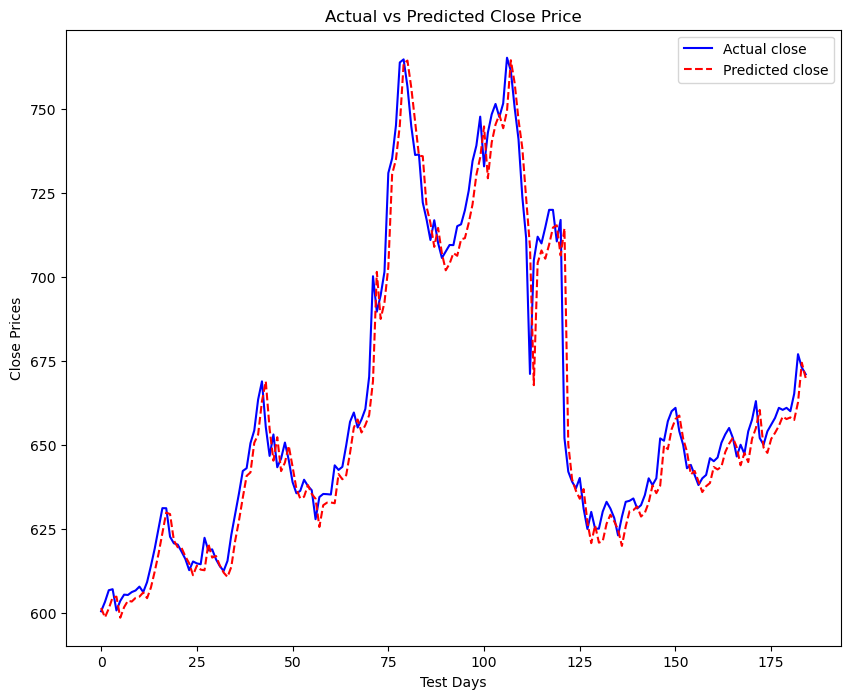

In [20]:
#actual vs predicted

plt.figure(figsize = (10,8))
plt.plot(y_test.values, label= 'Actual close', color= 'blue')
plt.plot(y_pred, label= 'Predicted close', color= 'red', linestyle = '--')
plt.title("Actual vs Predicted Close Price")
plt.xlabel("Test Days")
plt.ylabel("Close Prices")
plt.legend()
# plt.tight_layout()
plt.show()

In [21]:
y_pred

array([601.3541462 , 598.55981514, 601.1904003 , 604.52908032,
       604.73954378, 598.46051479, 601.60006647, 603.52483415,
       603.2795088 , 604.37118616, 604.73100144, 605.98507515,
       604.28657204, 607.44176832, 612.25498713, 617.55892718,
       623.68394196, 629.79827165, 629.34236838, 621.47665705,
       619.46245925, 619.27992678, 616.74761842, 614.65532341,
       611.1251732 , 613.98185039, 612.79411682, 612.60457654,
       620.52238579, 616.38219078, 616.85005098, 614.02881123,
       611.90591064, 610.60518024, 613.62300864, 621.35236767,
       627.40889864, 634.25085114, 640.72245798, 641.76400776,
       650.59847068, 653.03329893, 662.96023855, 668.90580629,
       654.73153551, 645.26031085, 652.24277336, 642.14856253,
       644.70763533, 649.68205236, 643.43693932, 636.88637537,
       633.98104853, 634.5038967 , 637.97325972, 635.32044743,
       633.91425694, 625.50895862, 631.98599922, 632.75604566,
       632.79514884, 632.57302946, 641.26843377, 639.71

In [24]:
tomorrow_price = model.predict(X_test_scaled)[-1]
print(f"Predicted Close for Tomorrow: {tomorrow_price:.2f}")

Predicted Close for Tomorrow: 669.90
